In [3]:
import os
import pandas as pd
from utils.feature_extraction import extract_tree_features
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

folder_path = 'data/train_data'

all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.laz')]

with ProcessPoolExecutor() as executor:
    features = list(tqdm(executor.map(extract_tree_features, all_files), total = len(all_files)))

results = [f for f in features if f is not None]

df = pd.DataFrame(results)

100%|██████████| 17707/17707 [06:05<00:00, 48.49it/s] 


In [4]:
from sklearn.model_selection import train_test_split

labels_df = pd.read_csv("data/train_data/labels.csv")                

print(f"Features (from laz): {len(df)}")
print(f"Labels (from csv):   {len(labels_df)}")

df['join_id'] = df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

labels_df['join_id'] = labels_df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

full_data = pd.merge(df, labels_df, on='join_id', how='inner')

print(f"Matched Trees: {len(full_data)}")

full_data['height_diff'] = abs(full_data['height'] - full_data['tree_H'])
print(f"Avg Height Diff: {full_data['height_diff'].mean():.2f}m")

clean_data = full_data[full_data['height_diff'] < 5.0].copy()
print(f"Trees after cleaning bad matches: {len(clean_data)}")

train_df, val_df = train_test_split(
    clean_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=clean_data['species']
)

cols_to_keep = [
    'height', 'volume', 'crown_area', 'num_points', 'crown_diameter', 'point_density', 'dbh_approx', 'p10_height_rel', 'p50_height_rel', 'p90_height_rel',
    'species', 'genus'
]

train_df[cols_to_keep].to_csv("train_dataset_final.csv", index=False)
val_df[cols_to_keep].to_csv("val_dataset_final.csv", index=False)

Features (from laz): 17707
Labels (from csv):   17707
Matched Trees: 17707
Avg Height Diff: 0.00m
Trees after cleaning bad matches: 17707


Entrainement complet

Model Accuracy: 63.61%
------------------------------
Classification Report:


c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                       precision    recall  f1-score   support

           Abies_alba       0.79      0.46      0.58        24
       Acer_campestre       0.38      0.52      0.44       248
  Acer_pseudoplatanus       0.65      0.70      0.67       115
       Acer_saccharum       0.77      0.45      0.57        22
       Betula_pendula       0.76      0.44      0.56       147
     Carpinus_betulus       0.35      0.26      0.30       249
     Corylus_avellana       0.40      0.22      0.29         9
   Crataegus_monogyna       0.35      0.15      0.21        46
   Eucalyptus_miniata       0.82      0.84      0.83        56
   Euonymus_europaeus       0.25      0.05      0.08        21
      Fagus_sylvatica       0.55      0.73      0.63       496
Fraxinus_angustifolia       0.71      0.48      0.57        21
   Fraxinus_excelsior       0.00      0.00      0.00        25
        Larix_decidua       0.71      0.26      0.38        19
          Picea_abies       0.72      0.80      0.76  

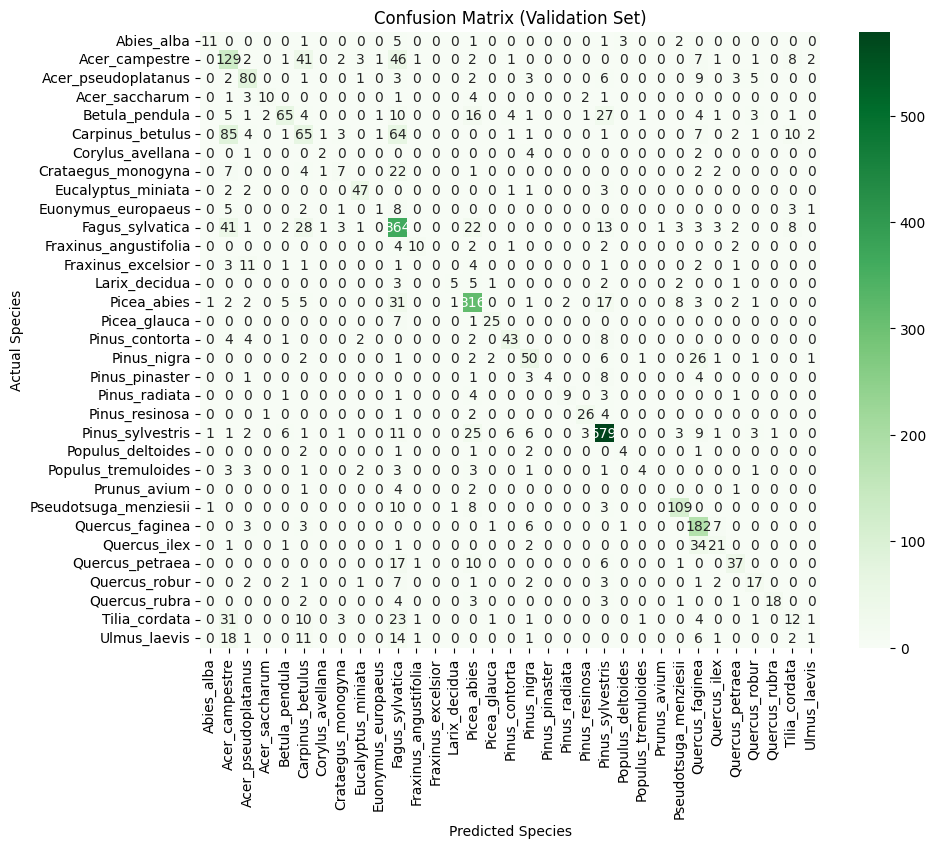

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

train_df = pd.read_csv("data/train_data/train_dataset_final.csv")
val_df = pd.read_csv("data/train_data/val_dataset_final.csv")

feature_cols = ['dbh_approx','p10_height_rel', 'p50_height_rel', 'p90_height_rel','height','num_points', 'crown_diameter', 'point_density', 'volume', 'crown_area']
target_col = 'species'

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train_encoded)

print("Entrainement complet")

y_pred = rf_model.predict(X_val)
accuracy = accuracy_score(y_val_encoded, y_pred)

print(f"\nModel Accuracy: {accuracy:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred, target_names=le.classes_))

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [ ]:
from utils.feature_extraction import extract_tree_features
from tqdm import tqdm

# --- 1. DEFINE PATHS & COLUMNS ---
test_folder = "./data/test_data"
# IMPORTANT: These must match exactly what you trained on
feature_cols = ['height', 'volume', 'crown_area', 'num_points'] 

# --- 2. REUSE FEATURE EXTRACTION ---
# We use the same function to ensure consistency
# (Make sure 'process_single_tree' is defined in your current session)
# If not, copy-paste the 'process_single_tree' function from the previous step here.

def extract_test_features():
    print(f"Scanning {test_folder}...")
    files = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.laz')]
    
    if not files:
        print("No .laz files found in test folder!")
        return pd.DataFrame()

    print(f"Found {len(files)} test trees. Extracting features...")
    
    # Parallel extraction
    with ProcessPoolExecutor() as executor:
        results = list(tqdm(executor.map(extract_tree_features, files), total=len(files)))
    
    # Filter out failures (None)
    clean_results = [r for r in results if r is not None]
    
    return pd.DataFrame(clean_results)

# --- 3. RUN EXTRACTION ---
test_df = extract_test_features()

if not test_df.empty:
    print(f"Successfully extracted features for {len(test_df)} trees.")

    # --- 4. PREDICT ---
    # Select only the feature columns (ignore filename for the prediction step)
    X_test = test_df[feature_cols]

    # Predict Class (0, 1, 2...)
    predictions_encoded = rf_model.predict(X_test)

    # Predict Probabilities (Confidence scores)
    # This tells us how sure the model is (e.g., 90% sure it's a Pine)
    probabilities = rf_model.predict_proba(X_test)
    confidence_scores = np.max(probabilities, axis=1)

    # Convert numbers back to names (0 -> "Eucalyptus")
    # We use the LabelEncoder (le) from the training step
    predictions_names = le.inverse_transform(predictions_encoded)

    # --- 5. COMPILE RESULTS ---
    results_df = pd.DataFrame({
        'filename': test_df['filename'],
        'predicted_species': predictions_names,
        'confidence': confidence_scores,
        # We include the features too, just for reference
        'height': test_df['height'],
        'volume': test_df['volume']
    })

    # Sort by low confidence (to see which trees confused the model)
    results_df = results_df.sort_values(by='confidence', ascending=True)

    # --- 6. SAVE & SHOW ---
    print("\n--- PREDICTION RESULTS (Lowest Confidence First) ---")
    print(results_df.head(10))
    
    output_filename = "test_predictions.csv"
    results_df.to_csv(output_filename, index=False)
    print(f"\n✅ Predictions saved to {output_filename}")

else:
    print("Extraction failed or folder was empty.")

Scanning ./data/test_data...
Found 2255 test trees. Extracting features...


100%|██████████| 2255/2255 [01:50<00:00, 20.33it/s]


Successfully extracted features for 2255 trees.


KeyError: "['point_count'] not in index"